# Min-Heap for Priority Queue Operations

Used to always retrieve the "next nearest city to visit" by distance.
Implemented as a binary heap using a Python list (array-based, no pointers).

- Insert: O(log n)
- Extract-min (peek + remove root): O(log n)
- Peek min: O(1)
- Build heap from n items: O(n) (heapify, not n inserts)

In [1]:
class CityData:
    def __init__(self, name, latitude, longitude, population, distance=0.0):
        self.name = name
        self.latitude = latitude
        self.longitude = longitude
        self.population = population
        self.distance = distance

    def __repr__(self):
        return f"City({self.name}, pop={self.population}, dist={self.distance})"

In [2]:
class MinHeap:
    """
    Array-based binary min-heap, ordered by CityData.distance.
    Smallest distance is always at index 0 (the root).
    """

    def __init__(self):
        self.heap = []  # list of CityData

    def __len__(self):
        return len(self.heap)

    def is_empty(self):
        return len(self.heap) == 0

    def _parent(self, i):
        return (i - 1) // 2

    def _left(self, i):
        return 2 * i + 1

    def _right(self, i):
        return 2 * i + 2

    def _swap(self, i, j):
        self.heap[i], self.heap[j] = self.heap[j], self.heap[i]

    def insert(self, city: CityData):
        self.heap.append(city)
        self._sift_up(len(self.heap) - 1)

    def _sift_up(self, i):
        while i > 0 and self.heap[i].distance < self.heap[self._parent(i)].distance:
            self._swap(i, self._parent(i))
            i = self._parent(i)

    def peek_min(self):
        return self.heap[0] if self.heap else None

    def extract_min(self):
        if not self.heap:
            return None
        min_city = self.heap[0]
        last = self.heap.pop()
        if self.heap:
            self.heap[0] = last
            self._sift_down(0)
        return min_city

    def _sift_down(self, i):
        n = len(self.heap)
        while True:
            smallest = i
            left, right = self._left(i), self._right(i)
            if left < n and self.heap[left].distance < self.heap[smallest].distance:
                smallest = left
            if right < n and self.heap[right].distance < self.heap[smallest].distance:
                smallest = right
            if smallest == i:
                break
            self._swap(i, smallest)
            i = smallest

    @classmethod
    def heapify(cls, cities):
        """Build a heap from a list of CityData in O(n) time."""
        h = cls()
        h.heap = list(cities)
        n = len(h.heap)
        for i in range(n // 2 - 1, -1, -1):
            h._sift_down(i)
        return h

## Sanity Test — simulating "visit nearest unvisited city" order

In [3]:
heap = MinHeap()
cities_with_dist = [
    ("Kathmandu", 0.0),
    ("Bhaktapur", 12.5),
    ("Lalitpur", 5.2),
    ("Pokhara", 200.0),
    ("Dhulikhel", 30.1),
    ("Nagarkot", 22.7),
]

for name, dist in cities_with_dist:
    heap.insert(CityData(name, 0, 0, 0, distance=dist))

print("Peek nearest:", heap.peek_min())
print("\nVisiting order (nearest first):")
while not heap.is_empty():
    print(" ->", heap.extract_min())

Peek nearest: City(Kathmandu, pop=0, dist=0.0)

Visiting order (nearest first):
 -> City(Kathmandu, pop=0, dist=0.0)
 -> City(Lalitpur, pop=0, dist=5.2)
 -> City(Bhaktapur, pop=0, dist=12.5)
 -> City(Nagarkot, pop=0, dist=22.7)
 -> City(Dhulikhel, pop=0, dist=30.1)
 -> City(Pokhara, pop=0, dist=200.0)


## Verify O(n) heapify vs repeated insert produce the same structure validity

In [4]:
import random

random.seed(42)
random_cities = [CityData(f"City{i}", 0, 0, 0, distance=random.uniform(0, 500)) for i in range(10)]

built_heap = MinHeap.heapify(random_cities)

order = []
while not built_heap.is_empty():
    order.append(built_heap.extract_min().distance)

print("Extracted order (should be ascending):", [round(d, 2) for d in order])
print("Is sorted ascending:", order == sorted(order))

Extracted order (should be ascending): [12.51, 14.9, 43.47, 111.61, 137.51, 210.96, 319.71, 338.35, 368.24, 446.09]
Is sorted ascending: True


## Visualizing the Heap Structure

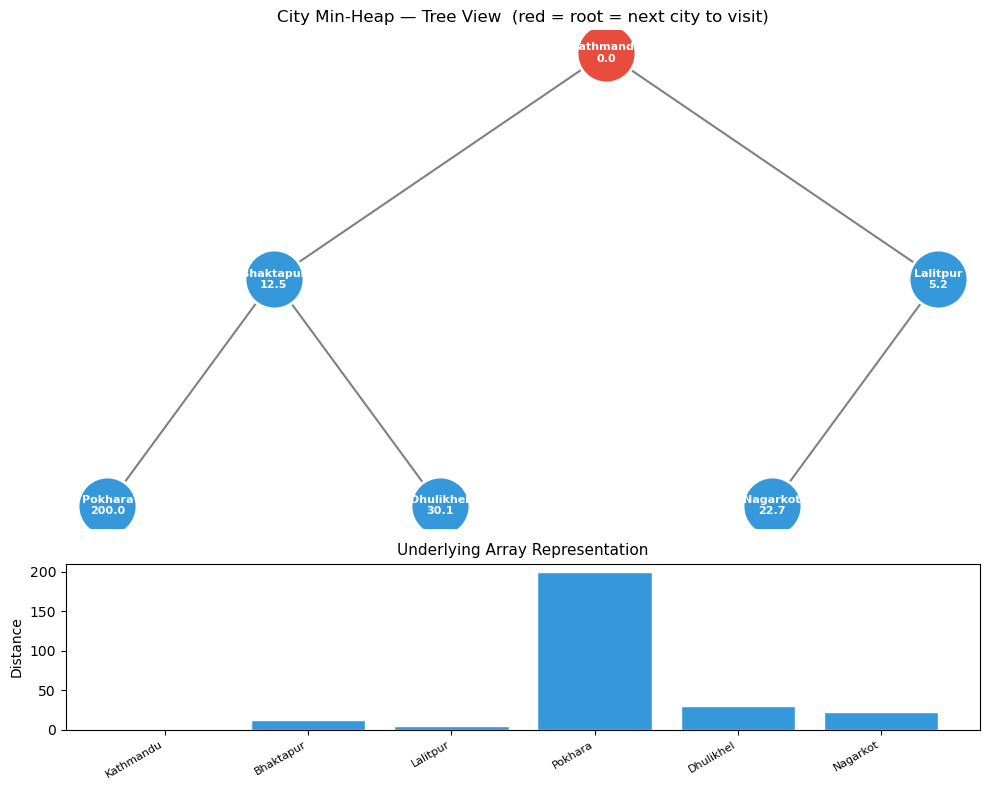

In [5]:
import matplotlib.pyplot as plt

def visualize_heap(heap_list, title="Min-Heap Structure"):
    """Draws the heap as a binary tree AND as its underlying array."""
    fig, (ax_tree, ax_array) = plt.subplots(2, 1, figsize=(10, 8),
                                              gridspec_kw={'height_ratios': [3, 1]})

    n = len(heap_list)

    # ---- Tree view ----
    def get_positions(n):
        """Assign (x, y) coordinates to each index for a clean tree layout."""
        positions = {}
        def assign(i, depth, x_min, x_max):
            if i >= n:
                return
            x = (x_min + x_max) / 2
            positions[i] = (x, -depth)
            assign(2*i + 1, depth + 1, x_min, x)
            assign(2*i + 2, depth + 1, x, x_max)
        assign(0, 0, 0, 1)
        return positions

    pos = get_positions(n)

    # draw edges first
    for i in range(n):
        for child in (2*i + 1, 2*i + 2):
            if child < n:
                x1, y1 = pos[i]
                x2, y2 = pos[child]
                ax_tree.plot([x1, x2], [y1, y2], color='gray', zorder=1, linewidth=1.5)

    # draw nodes
    for i in range(n):
        x, y = pos[i]
        city = heap_list[i]
        color = '#e74c3c' if i == 0 else '#3498db'
        ax_tree.scatter(x, y, s=1800, color=color, zorder=2, edgecolors='white', linewidth=2)
        ax_tree.text(x, y, f"{city.name}\n{city.distance:.1f}", ha='center', va='center',
                     color='white', fontsize=8, fontweight='bold', zorder=3)

    ax_tree.set_title(title + " — Tree View  (red = root = next city to visit)", fontsize=12)
    ax_tree.axis('off')

    # ---- Array view ----
    names = [c.name for c in heap_list]
    dists = [c.distance for c in heap_list]
    colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(n)]
    ax_array.bar(range(n), dists, color=colors, edgecolor='white')
    ax_array.set_xticks(range(n))
    ax_array.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    ax_array.set_ylabel("Distance")
    ax_array.set_title("Underlying Array Representation", fontsize=11)

    plt.tight_layout()
    plt.show()

# Rebuild the heap from earlier (since we emptied it via extract_min)
heap2 = MinHeap()
for name, dist in cities_with_dist:
    heap2.insert(CityData(name, 0, 0, 0, distance=dist))

visualize_heap(heap2.heap, "City Min-Heap")
